In [1]:
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz, get_body, ICRS
import astropy.constants as c
from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
import astropy.units as u
from astropy.visualization.wcsaxes.frame import EllipticalFrame
from astropy.visualization.wcsaxes import WCSAxes

from astroquery.hips2fits import hips2fits
hips2fits.timeout = 300 # Necessary to prevent timeouts for downloading large files

from matplotlib import patheffects
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from astropy.table import Table
import pandas as pd
import matplotlib.cm as cm
import os

from regions import Regions, PolygonSkyRegion

%matplotlib widget

hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
global hatch_idx
hatch_idx = 0

In [2]:
data = Table.read('reuter_2020_data/smg_dndz_tables.fits', hdu=1)
data.sort('z_spec')

results = {
'SPT2354-58' : True ,
'SPT0611-55' : True ,
'SPT0512-59' : True ,
'SPT0002-52' : True ,
'SPT2031-51' : False ,
'SPT0604-64' : False ,
'SPT2311-45' : False ,
'SPT0125-47' : True ,
'SPT0551-48' : True ,
'SPT0402-45' : True ,
'SPT2332-53' : True ,
'SPT0625-58' : True ,
'SPT2134-50' : True ,
'SPT0538-50' : True ,
'SPT0150-59' : False ,
'SPT2349-50' : False ,
'SPT2232-61' : True ,
'SPT0314-44' : True ,
'SPT2357-51' : False ,
'SPT0103-45' : False ,
'SPT0550-53' : False ,
'SPT2316-50' : False ,
'SPT2101-60' : False ,
'SPT0551-50' : True ,
'SPT0226-45' : True ,
'SPT2129-57' : False ,
'SPT0652-55' : True ,
'SPT0529-54' : False ,
'SPT0532-50' : True ,
'SPT0516-59' : False ,
'SPT0112-55' : False ,
'SPT0027-50' : True ,
'SPT0300-46' : True ,
'SPT0109-47' : True ,
'SPT2147-50' : False ,
'SPT0520-53' : False ,
'SPT2152-40' : False ,
'SPT0436-40' : False ,
'SPT2340-59' : False ,
'SPT2349-52' : False ,
'SPT0125-50' : False ,
'SPT0457-49' : False ,
'SPT2037-65' : False ,
'SPT0403-58' : False ,
'SPT2048-55' : False ,
'SPT0020-51' : False ,
'SPT0418-47' : False ,
'SPT0113-46' : False ,
'SPT0544-40' : False ,
'SPT2311-54' : False ,
'SPT0345-47' : True ,
'SPT0136-63' : False ,
'SPT2349-56' : False ,
'SPT0155-62' : False ,
'SPT2103-60' : False ,
'SPT0552-42' : False ,
'SPT0441-46' : False ,
'SPT0319-47' : False ,
'SPT2146-55' : False ,
'SPT0528-53' : False ,
'SPT2335-53' : False ,
'SPT2132-58' : False ,
'SPT0459-59' : False ,
'SPT0147-64' : False ,
'SPT0555-62' : False ,
'SPT0459-58' : False ,
'SPT0054-41' : False ,
'SPT0106-64' : True ,
'SPT0452-50' : False ,
'SPT0202-61' : False ,
'SPT0425-40' : False ,
'SPT2203-41' : False ,
'SPT2319-55' : False ,
'SPT0553-50' : False ,
'SPT2353-50' : False ,
'SPT0245-63' : False ,
'SPT0348-62' : False ,
'SPT0346-52' : True ,
'SPT0243-49' : False ,
'SPT2351-57' : False ,
'SPT0311-58' : False ,
}

def galactic_to_radec(l_list, b_list=None):
    """
    Convert galactic coordinates (l, b) to equatorial coordinates (RA, Dec).

    Parameters
    ----------
    l_list : list or array-like
        Galactic longitudes in degrees.
    b_list : list or array-like, optional
        Galactic latitudes in degrees. If None, assumes b=0 for all points.

    Returns
    -------
    ra_list : list
        Right Ascension in degrees.
    dec_list : list
        Declination in degrees.
    """
    if b_list is None: b_list = [0]*len(l_list)
    # Create SkyCoord object in Galactic frame
    galactic_coords = SkyCoord(l=l_list*u.degree, b=b_list*u.degree, frame='galactic')
    
    # Transform to Equatorial (ICRS) frame
    equatorial_coords = galactic_coords.icrs
    
    # Return RA and Dec in degrees as lists
    ra_list = equatorial_coords.ra.degree.tolist()
    dec_list = equatorial_coords.dec.degree.tolist()

    # Convert to string format
    '''
    ra_hms = equatorial_coords.ra.to_string(unit=u.hour, sep=':', pad=True)
    dec_dms = equatorial_coords.dec.to_string(unit=u.degree, sep=':', pad=True, alwayssign=True)

    ra_list = ra_hms.tolist()
    dec_list = dec_dms.tolist()
    '''

    return ra_list, dec_list
#-----------------------------------------------------------------
list_galactic_longitude = np.linspace(230, 280, 15, endpoint=True) 
ra_list, dec_list = galactic_to_radec(list_galactic_longitude)
ra_extrems, dec_extrems = galactic_to_radec((230, 255,280))


In [3]:
ra_extrems,dec_extrems

([110.82913687713727, 125.2291777802729, 150.00353903713994],
 [-15.142367637493548, -36.605622361777904, -55.04986525706471])

In [4]:
def wrap360(ang):
    return ((ang + 360.) % 360.)

In [5]:
EL_MIN = 20
EL_MAX = 52
DAZ_MIN = 90
DAZ_MAX = 225
az_limleft = lambda x: wrap360(x - 270)
az_limright = lambda x: wrap360(x - 135)


mcmurdo = EarthLocation(lat='-77.8419', lon='166.6863', height=37000.)
# mcmurdo = EarthLocation(lat='-77.8419', lon='346.6863', height=37000.) # halfway around continent
launch_date = Time('2027-12-25 00:00:00', scale='utc', location=mcmurdo)

step_hr = 1
oneday = np.arange(0, 24 + step_hr, step_hr) * u.hr
oneweek = np.arange(0, 24 * 7 + step_hr, step_hr) * u.hr
threeweeks = np.arange(0, (24 * 7 * 3) + step_hr, step_hr) * u.hr

times = launch_date + threeweeks
t = (times - times[0]).to(u.hr)

sun_body = get_body('sun', times, location=mcmurdo)
sun = SkyCoord(ra=sun_body.ra, dec=sun_body.dec, obstime=times, location=mcmurdo)
sun_altaz = sun.transform_to('altaz')

gal_center = SkyCoord(ra='17h45m40.04s', dec='-29d00m28.s', obstime=times[0], location=mcmurdo)

goods_s = SkyCoord(ra='3h32m36.51s', dec='-27d47m33.74s', obstime=times, location=mcmurdo)
goods_s_altaz = goods_s.transform_to('altaz')

edfs = SkyCoord(ra='04h04m57.84s', dec='-48d25m22.8s', obstime=times[0], location=mcmurdo)

edff = SkyCoord(ra='03h31m43.6s', dec='-28d05m18.6s', obstime=times[0], location=mcmurdo)

spt_summer = SkyCoord(ra='0h0m0s', dec='-57d30m0s', obstime=times[0], location=mcmurdo) # 500 deg^2
spt_winter = SkyCoord(ra='0h0m0s', dec='-66d0m0s', obstime=times[0], location=mcmurdo) # 1500 deg^2


In [ ]:
data = Table.read('reuter_2020_data/smg_dndz_tables.fits', hdu=1)
data.sort('z_spec')

results = {
'SPT2354-58' : True ,
'SPT0611-55' : True ,
'SPT0512-59' : True ,
'SPT0002-52' : True ,
'SPT2031-51' : False ,
'SPT0604-64' : False ,
'SPT2311-45' : False ,
'SPT0125-47' : True ,
'SPT0551-48' : True ,
'SPT0402-45' : True ,
'SPT2332-53' : True ,
'SPT0625-58' : True ,
'SPT2134-50' : True ,
'SPT0538-50' : True ,
'SPT0150-59' : False ,
'SPT2349-50' : False ,
'SPT2232-61' : True ,
'SPT0314-44' : True ,
'SPT2357-51' : False ,
'SPT0103-45' : False ,
'SPT0550-53' : False ,
'SPT2316-50' : False ,
'SPT2101-60' : False ,
'SPT0551-50' : True ,
'SPT0226-45' : True ,
'SPT2129-57' : False ,
'SPT0652-55' : True ,
'SPT0529-54' : False ,
'SPT0532-50' : True ,
'SPT0516-59' : False ,
'SPT0112-55' : False ,
'SPT0027-50' : True ,
'SPT0300-46' : True ,
'SPT0109-47' : True ,
'SPT2147-50' : False ,
'SPT0520-53' : False ,
'SPT2152-40' : False ,
'SPT0436-40' : False ,
'SPT2340-59' : False ,
'SPT2349-52' : False ,
'SPT0125-50' : False ,
'SPT0457-49' : False ,
'SPT2037-65' : False ,
'SPT0403-58' : False ,
'SPT2048-55' : False ,
'SPT0020-51' : False ,
'SPT0418-47' : False ,
'SPT0113-46' : False ,
'SPT0544-40' : False ,
'SPT2311-54' : False ,
'SPT0345-47' : True ,
'SPT0136-63' : False ,
'SPT2349-56' : False ,
'SPT0155-62' : False ,
'SPT2103-60' : False ,
'SPT0552-42' : False ,
'SPT0441-46' : False ,
'SPT0319-47' : False ,
'SPT2146-55' : False ,
'SPT0528-53' : False ,
'SPT2335-53' : False ,
'SPT2132-58' : False ,
'SPT0459-59' : False ,
'SPT0147-64' : False ,
'SPT0555-62' : False ,
'SPT0459-58' : False ,
'SPT0054-41' : False ,
'SPT0106-64' : True ,
'SPT0452-50' : False ,
'SPT0202-61' : False ,
'SPT0425-40' : False ,
'SPT2203-41' : False ,
'SPT2319-55' : False ,
'SPT0553-50' : False ,
'SPT2353-50' : False ,
'SPT0245-63' : False ,
'SPT0348-62' : False ,
'SPT0346-52' : True ,
'SPT0243-49' : False ,
'SPT2351-57' : False ,
'SPT0311-58' : False ,
}

def galactic_to_radec(l_list, b_list=None):
    """
    Convert galactic coordinates (l, b) to equatorial coordinates (RA, Dec).

    Parameters
    ----------
    l_list : list or array-like
        Galactic longitudes in degrees.
    b_list : list or array-like, optional
        Galactic latitudes in degrees. If None, assumes b=0 for all points.

    Returns
    -------
    ra_list : list
        Right Ascension in degrees.
    dec_list : list
        Declination in degrees.
    """
    if b_list is None: b_list = [0]*len(l_list)
    # Create SkyCoord object in Galactic frame
    galactic_coords = SkyCoord(l=l_list*u.degree, b=b_list*u.degree, frame='galactic')
    
    # Transform to Equatorial (ICRS) frame
    equatorial_coords = galactic_coords.icrs
    
    # Return RA and Dec in degrees as lists
    ra_list = equatorial_coords.ra.degree.tolist()
    dec_list = equatorial_coords.dec.degree.tolist()

    # Convert to string format
    '''
    ra_hms = equatorial_coords.ra.to_string(unit=u.hour, sep=':', pad=True)
    dec_dms = equatorial_coords.dec.to_string(unit=u.degree, sep=':', pad=True, alwayssign=True)

    ra_list = ra_hms.tolist()
    dec_list = dec_dms.tolist()
    '''

    return ra_list, dec_list
#-----------------------------------------------------------------
list_galactic_longitude = np.linspace(230, 280, 15, endpoint=True) 
ra_list, dec_list = galactic_to_radec(list_galactic_longitude)
ra_extrems, dec_extrems = galactic_to_radec((230, 255,280))


spt_smgs = []
spt_names = []
spt_ids = []
for ismg, smg in enumerate(data):
    if(results[smg['spt_id']]): 
        smg_coords = SkyCoord(ra=smg['RA']*u.deg, dec=smg['DEC']*u.deg, obstime=times[0], location=mcmurdo)
        spt_smgs.append(smg_coords)
        spt_names.append(smg['spt_id']+f", z={smg['z_spec']:.1f}")
        spt_ids.append(smg['spt_id'])
colors = cm.plasma(np.linspace(0,1,len(spt_smgs)))

list_galactic_longitude_skycoord = []
ra_list, dec_list = galactic_to_radec(list_galactic_longitude)
for (ra,dec) in zip(np.asarray(ra_list),np.asarray(dec_list)):
    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, obstime=times[0], location=mcmurdo)
    list_galactic_longitude_skycoord.append(coords)
colors_longitues = cm.viridis(np.linspace(0,1,len(list_galactic_longitude_skycoord)))


In [6]:
def plot_from_catalog_helper_t_vs_el(ax, name, skycoord_override=None):
    global hatch_idx
    if not skycoord_override:
        foo = SkyCoord.from_name(name)
        coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    else:
        coord = skycoord_override
    foo_altaz = coord.transform_to(AltAz)
    l, = ax.plot(t, foo_altaz.alt.deg, marker='.', label=name)

    in_bounds = np.where((foo_altaz.alt.deg >= EL_MIN) & (foo_altaz.alt.deg <= EL_MAX))[0]
    for i0, i1 in zip(range(len(t))[:-1], range(len(t))[1:]):
        if (i0 in in_bounds) and (i1 in in_bounds):
            ax.axvspan(t[i0].value, t[i1].value, alpha=0.2, color=l.get_color(), hatch=hatches[hatch_idx])
    hatch_idx += 1
    return coord, foo_altaz


def plot_from_catalog_helper_t_vs_az(ax, name, skycoord_override=None):
    if not skycoord_override:
        foo = SkyCoord.from_name(name)
        coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    else:
        coord = skycoord_override
    foo_altaz = coord.transform_to(AltAz)
    l, = ax.plot(t, foo_altaz.az.deg, marker='.', label=name)

    return coord, foo_altaz


def plot_from_catalog_helper_t_vs_delta_sun(ax, name, skycoord_override=None):
    global hatch_idx
    if not skycoord_override:
        foo = SkyCoord.from_name(name)
        coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    else:
        coord = skycoord_override
    foo_altaz = coord.transform_to(AltAz)

    sun_body = get_body('sun', times, location=mcmurdo)
    sun = SkyCoord(ra=sun_body.ra, dec=sun_body.dec, obstime=times, location=mcmurdo)
    sun_altaz = sun.transform_to('altaz')

    delta_az = wrap360(foo_altaz.az.deg - sun_altaz.az.deg)
    l, = ax.plot(t, delta_az, marker='.', label=f'{name} Az - Sun Az')

    in_bounds = np.where((delta_az >= DAZ_MIN) & (delta_az <= DAZ_MAX))[0]
    for i0, i1 in zip(range(len(t))[:-1], range(len(t))[1:]):
        if (i0 in in_bounds) and (i1 in in_bounds):
            ax.axvspan(t[i0].value, t[i1].value, alpha=0.2, color=l.get_color(), hatch=hatches[hatch_idx])
    hatch_idx += 1
    return coord, foo_altaz, sun_altaz

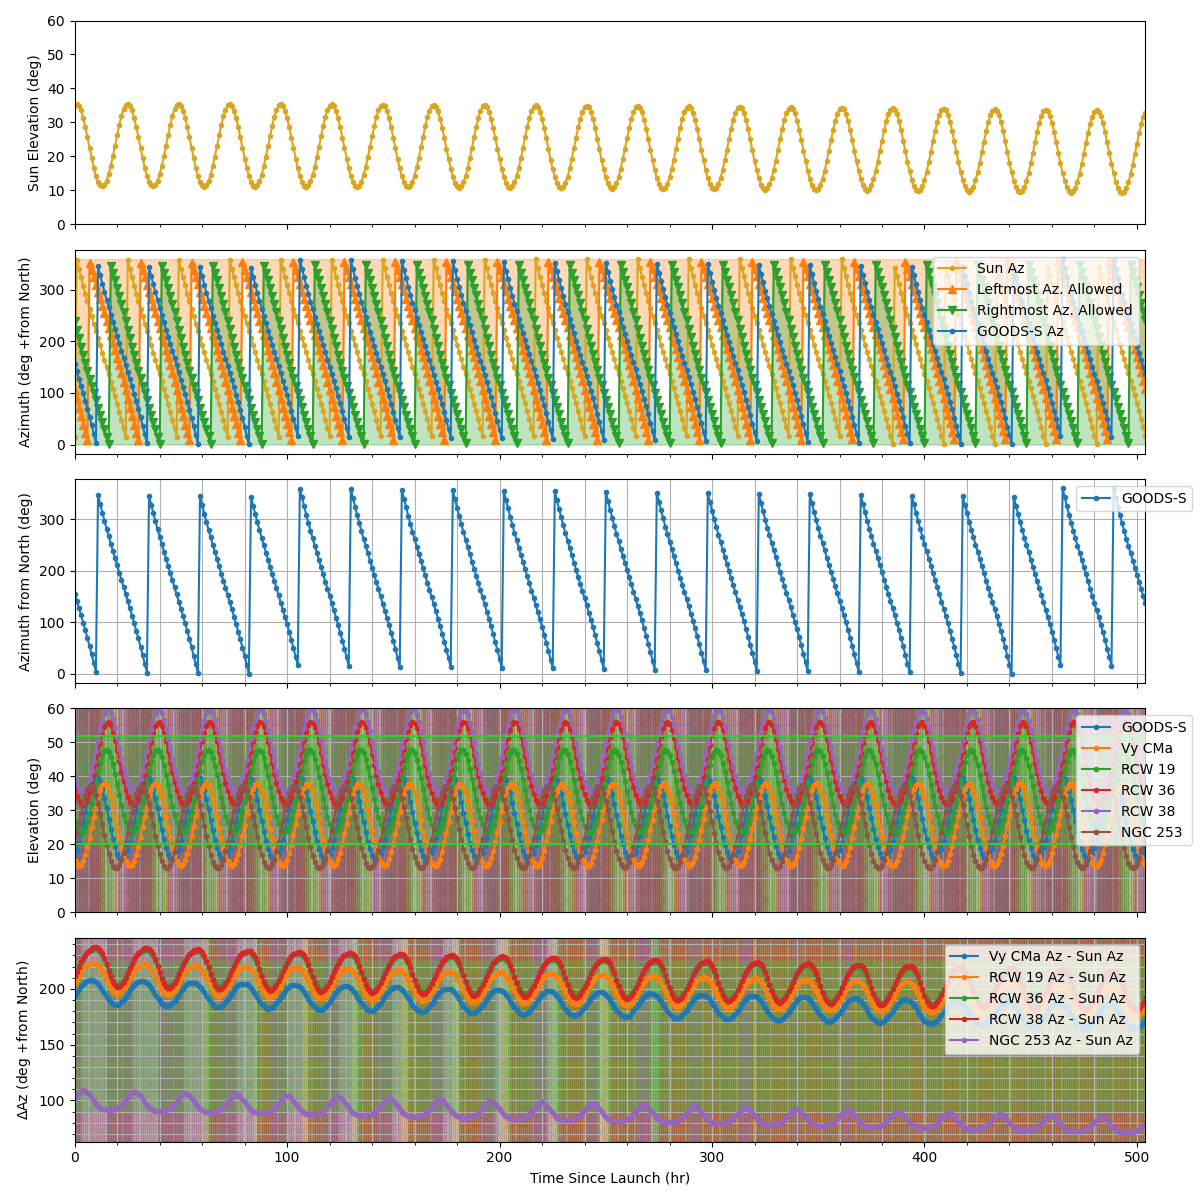

In [7]:
fig, ax = plt.subplots(figsize=(12,12), nrows=5, sharex=True)

ax[0].plot(t, sun_altaz.alt.deg, marker='.', color='goldenrod')
ax[0].set_ylim(0, 60)
ax[0].set_ylabel('Sun Elevation (deg)')

ax[1].plot(t, sun_altaz.az.deg, marker='.', color='goldenrod', label='Sun Az')
ax[1].plot(t, az_limleft(sun_altaz.az.deg), marker='^', color='C1', label='Leftmost Az. Allowed')
ax[1].fill_between(t.value, az_limleft(sun_altaz.az.deg), color='C1', y2=360, alpha=0.3)
ax[1].plot(t, az_limright(sun_altaz.az.deg), marker='v', color='C2', label='Rightmost Az. Allowed')
ax[1].fill_between(t.value, az_limright(sun_altaz.az.deg), color='C2', y2=0, alpha=0.3)
ax[1].plot(t, goods_s_altaz.az.deg, marker='.', label='GOODS-S Az')
ax[1].set_ylabel('Azimuth (deg +from North)')
ax[1].legend(loc='upper right')

plot_from_catalog_helper_t_vs_az(ax[2], 'GOODS-S', skycoord_override=goods_s)
ax[2].set_ylabel('Azimuth from North (deg)')
ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper right')
ax[2].grid(which='both')
ax[2].set_xlim(t[0].value, t[-1].value)

hatch_idx = 0
plot_from_catalog_helper_t_vs_el(ax[3], 'GOODS-S', skycoord_override=goods_s)
plot_from_catalog_helper_t_vs_el(ax[3], 'Vy CMa')
rcw19, _, = plot_from_catalog_helper_t_vs_el(ax[3], 'RCW 19')
# rcw20, _ = plot_from_catalog_helper_t_vs_el(ax[3], 'RCW 20')
rcw36, _ = plot_from_catalog_helper_t_vs_el(ax[3], 'RCW 36')
rcw38, _ = plot_from_catalog_helper_t_vs_el(ax[3], 'RCW 38')
plot_from_catalog_helper_t_vs_el(ax[3], 'NGC 253')
# plot_from_catalog_helper_t_vs_el(ax[3], 'HH 47')
# plot_from_catalog_helper_t_vs_el(ax[3], 'TW Hydrae')
# plot_from_catalog_helper_t_vs_el(ax[3], '[MHL2007] G259.0453-01.5559 1')
# plot_from_catalog_helper_t_vs_el(ax[3], 'IRAS 08088-3554')
# plot_from_catalog_helper_t_vs_el(ax[3], 'CG 30')
# plot_from_catalog_helper_t_vs_el(ax[3], 'IRAS 08448-4343')
# rcw38, _ = plot_from_catalog_helper_t_vs_el(ax[3], 'M42')

ax[3].axhline(EL_MIN, color='limegreen')
ax[3].fill_between(t.value, EL_MIN, y2=EL_MAX, color='limegreen', alpha=0.3)
ax[3].axhline(EL_MAX, color='limegreen')
ax[3].set_ylim(0, 60)
ax[3].set_ylabel('Elevation (deg)')
ax[3].legend(bbox_to_anchor=(1.05, 1), loc='upper right')
ax[3].grid(which='both')
ax[3].set_xlim(t[0].value, t[-1].value)

hatch_idx = 0
# plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'GOODS-S', skycoord_override=goods_s)
plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'Vy CMa')
plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'RCW 19')
plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'RCW 36')
plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'RCW 38')
plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'NGC 253')
# plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'HH 47')
# plot_from_catalog_helper_t_vs_delta_sun(ax[4], 'TW Hydrae')

ax[4].fill_between(t.value, DAZ_MIN, y2=DAZ_MAX, color='limegreen', alpha=0.3)
ax[4].set_ylabel('$\Delta$Az (deg +from North)')
ax[4].legend(loc='upper right')
ax[4].grid(which='both')
# ax[4].set_ylim(0, 360)
ax[4].set_xlabel('Time Since Launch (hr)')

plt.minorticks_on()
plt.tight_layout()

In [8]:
def altaz_to_radec_helper(alt, az):
    my_radec = SkyCoord(
        AltAz(
            alt=alt,
            az=az,
            obstime=times,
            location=mcmurdo
        )
    ).transform_to(ICRS)
    return my_radec

In [9]:
def plot_from_catalog_helper(ax, name, label=None, color=None):
    if(type(name)==str):
        foo = SkyCoord.from_name(name)
        label=name
    else: foo = name
    coord = SkyCoord(foo.ra, foo.dec, obstime=times, location=mcmurdo)
    if(color is None): ax.scatter(coord.ra, coord.dec, s=75, edgecolor='k', transform=ax.get_transform('icrs'), label=label)
    else: ax.scatter(coord.ra, coord.dec, s=75, edgecolor='k', color=color,transform=ax.get_transform('icrs'), label=label)
    return foo

Plot a polygon on sky connecting the RA/Dec coordinates dictated by the el axis limits and the sun. One polygon per time coordinate

In [10]:
def allsky_query(hips, reload=False):
    fname = hips.replace('/', '_') + '.fits'
    if os.path.exists(fname) and reload or not os.path.exists(fname):
        result = hips2fits.query(
            hips=hips,
            ra=0 * u.deg,
            dec=0 * u.deg,
            width=5000,
            height=2500,
            fov=360 * u.deg,
            projection='MOL',
            get_query_payload=False,
            format='fits',
        )
        result.writeto(fname, overwrite=True)

    hdu = fits.open(fname)
    h = hdu[0].header
    wcs = WCS(h, naxis=2) # reduce WCS dimensionality for polygon overplot
    d = hdu[0].data
    return wcs, h, d


In [11]:
# https://alasky.cds.unistra.fr/hips-image-services/hips2fits
wcs, h, d0 = allsky_query('CDS/P/IRIS/color', reload=False)

In [12]:
wcs, h, d1 = allsky_query('ESAVO/P/HERSCHEL/SPIRE-350', reload=False)

In [13]:
import healpy as hp
from reproject import reproject_from_healpix
 
# Download from the Planck Legacy Archive:
# HFI_CompMap_CO-Type1_2048_R2.00.fits
 '''
cofile = "HFI_CompMap_CO-Type1_2048_R2.00.fits"

# Reproject the CO(1-0) map (I10 field) onto the same Mollweide WCS
d1, footprint = reproject_from_healpix(
    (cofile, "I10"),
    wcs,
    shape_out=d0.shape,
    nested=False,
)  
'''

IndentationError: unexpected indent (2365715183.py, line 6)

In [ ]:
ds = [d1, d0]

TypeError: Invalid shape (4, 2500, 5000) for image data

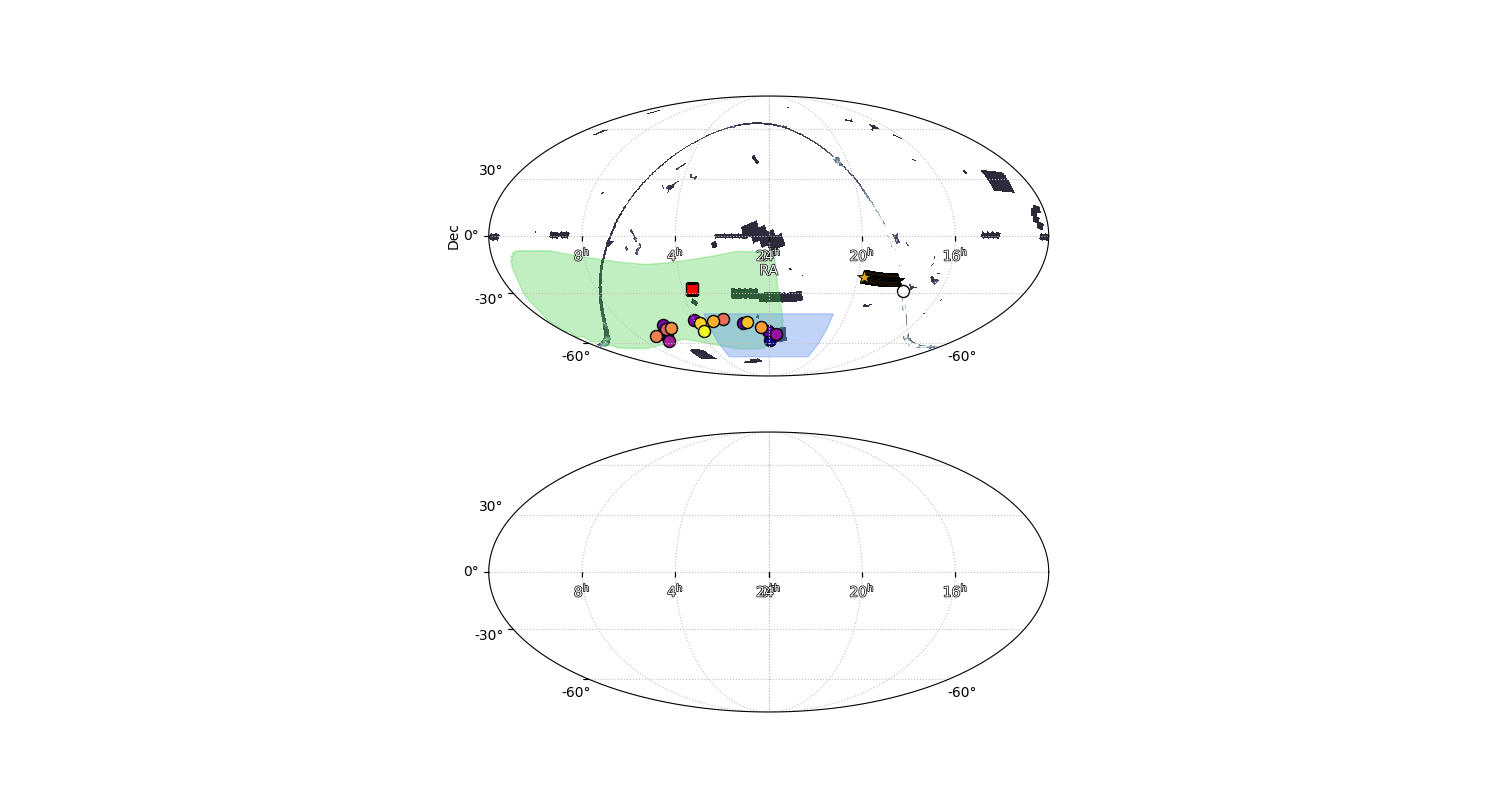

In [ ]:
fig, axs = plt.subplots(figsize=(15,8), nrows=2, subplot_kw=dict(projection=wcs, frame_class=EllipticalFrame), sharex=True, sharey=True)
ax0, ax1 = axs

for j, ax in enumerate(axs):
    d = ds[j]

    lon = ax.coords[0]
    lat = ax.coords[1]
    lat.set_axislabel_position("c")

    path_effects=[patheffects.withStroke(linewidth=1, foreground='black')]
    lon.set_ticklabel(color='white', path_effects=path_effects)
    ax.grid(linestyle=':', color='silver')

    ax.imshow(d, vmin=np.nanmin(d), vmax=np.nanmean(d) + 2 * np.nanstd(d), cmap='bone')

    p = ax.scatter(sun.ra, sun.dec, s=100, marker='*', facecolor='goldenrod', edgecolor='k', linewidth=.5, transform=ax.get_transform('icrs'), label='Sun')

    limleftup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limrightup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limright(sun_altaz.az.deg) * u.deg)

    # coordinates of corners on plot
    # p = ax.scatter(limleftup_radec.ra, limleftup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftmid_radec.ra, limleftmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftdown_radec.ra, limleftdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightup_radec.ra, limrightup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightmid_radec.ra, limrightmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightdown_radec.ra, limrightdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))

    rs = []
    for i in range(len(limleftup_radec)):
        verts = SkyCoord([
                limleftup_radec.ra[i],
                limleftmid_radec.ra[i],
                limleftdown_radec.ra[i],
                limrightdown_radec.ra[i],
                limrightmid_radec.ra[i],
                limrightup_radec.ra[i],
            ],
            [
                limleftup_radec.dec[i],
                limleftmid_radec.dec[i],
                limleftdown_radec.dec[i],
                limrightdown_radec.dec[i],
                limrightmid_radec.dec[i],
                limrightup_radec.dec[i],
            ],
            unit='deg',
            frame=ICRS
        )
        reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='limegreen', linewidth=2, facecolor=None))
        rs.append(reg)
    regions = Regions(rs)
    regions.write('myregions.reg', format='ds9', overwrite=True)

    px_regions = [r.to_pixel(wcs) for r in rs]
    '''
    for i, p in enumerate(px_regions):
        if i == 0:
            p.plot(ax=ax, edgecolor='limegreen', facecolor='limegreen', alpha=max(1/len(times), 0.2), label='Boresight Valid')
        # p.plot(ax=ax, edgecolor='k', alpha=max(1/len(times), 0.01))
        p.plot(ax=ax, facecolor='none', edgecolor='limegreen', alpha=0.2)
    '''

    from shapely.ops import unary_union
    from shapely.geometry import Polygon
    from regions import PolygonPixelRegion

    # Convert each sky region to pixel polygons
    px_regions = [r.to_pixel(wcs) for r in rs]

    # Extract vertices in pixel coordinates
    polygons = []
    for r in px_regions:
        x = r.vertices.x
        y = r.vertices.y
        polygons.append(Polygon(zip(x, y)))

    # Combine all footprints
    combined = unary_union(polygons)

    # Plot combined footprint
    if combined.geom_type == "Polygon":
        x, y = combined.exterior.xy
        ax.fill(x, y, facecolor="limegreen", edgecolor="limegreen",
                alpha=0.3, label="Boresight Valid")
        
    elif combined.geom_type == "MultiPolygon":
        for j, poly in enumerate(combined.geoms):
            x, y = poly.exterior.xy
            ax.fill(x, y, facecolor="limegreen", edgecolor="limegreen",
                    alpha=0.3, label="Boresight Valid" if j == 0 else None)

    # some additional points of interest
    ax.scatter(gal_center.ra, gal_center.dec, s=75, facecolor='w', edgecolor='k', transform=ax.get_transform('icrs'), label='Gal. Center')
    ax.scatter(goods_s.ra, goods_s.dec, s=75, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='GOODS-S', color='r')
    #ax.scatter(edfs.ra, edfs.dec, s=75, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field South')
    # ax.scatter(edff.ra, edff.dec, marker='s', linewidth=0.5, edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field Fornax')

    verts = SkyCoord([
                '20h40m0s',
                '20h40m0s',
                '20h40m0s',
                '20h40m0s',
                '3h20m0s',
                '3h20m0s',
                '3h20m0s',
                '3h20m0s',
            ],
            [
                '-70d0m0s',
                '-60d0m0s',
                '-50d0m0s',
                '-42d0m0s',
                '-42d0m0s',
                '-50d0m0s',
                '-60d0m0s',
                '-70d0m0s',
            ],
            unit='deg',
            frame=ICRS
    )# https://www.researchgate.net/publication/348251485_Measurements_of_the_E-Mode_Polarization_and_Temperature-E-Mode_Correlation_of_the_CMB_from_SPT-3G_2018_Data/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6Il9kaXJlY3QiLCJwYWdlIjoiX2RpcmVjdCJ9fQ
    spt_reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='cornflowerblue', linewidth=1, facecolor=None))
    px_region = spt_reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='cornflowerblue', edgecolor='cornflowerblue', alpha=0.4, label='SPT-3G 1500deg$^2$')

    
    #rcw19 = plot_from_catalog_helper(ax, 'RCW 19')
    # rcw20 = plot_from_catalog_helper(ax, 'RCW 20')
    #rcw36 = plot_from_catalog_helper(ax, 'RCW 36')
    #rcw38 = plot_from_catalog_helper(ax, 'RCW 38')
    # plot_from_catalog_helper(ax, 'RCW 42')
    # plot_from_catalog_helper(ax, 'RCW 49')
    # carina = plot_from_catalog_helper(ax, 'Carina Nebula')
    # plot_from_catalog_helper(ax, 'NGC 253')
    # plot_from_catalog_helper(ax, 'HH 47')
    # plot_from_catalog_helper(ax, 'TW Hydrae')
    # plot_from_catalog_helper(ax, 'NGC 3576')
    # plot_from_catalog_helper(ax, 'NGC 3603')
    # plot_from_catalog_helper(ax, 'Vela Molecular Ridge')
    # plot_from_catalog_helper(ax, 'Beta Gruis')
    # plot_from_catalog_helper(ax, '[MHL2007] G259.0453-01.5559 1') # Young Stellar Object Candidate
    # plot_from_catalog_helper(ax, 'NGC 2579')
    # plot_from_catalog_helper(ax, 'IRAS 08088-3554')
    # plot_from_catalog_helper(ax, 'CG 30')
    # plot_from_catalog_helper(ax, 'IRAS 08448-4343')

    # for hh in [120, 132, 133, 171, 188, 217, 219, 246]: # [46, 47, 72, 73, 74, 75,]
    #     plot_from_catalog_helper(ax, 'HH' + str(hh))


    ax.set_xlabel('RA', color='w', path_effects=path_effects)
    ax.set_ylabel('Dec')
    
    
    #plot_from_catalog_helper(ax, 'Vy CMa')
    excluded = ('SPT0106-64','SPT0512-59','SPT0314-44', 'SPT2232-61','SPT2134-50')#'SPT0345-47') #SPT0346-52
    for i in range(len(spt_smgs)):
        if(spt_ids[i] not in excluded): 
            plot_from_catalog_helper(ax, spt_smgs[i], label=spt_names[i], color=colors[i])

handles, labels = ax0.get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.7, 0.5),
    frameon=True,
    ncol=1,
)
#ax0.legend(loc='upper right', ncol=1, bbox_transform=fig.transFigure, bbox_to_anchor=(0.8, 1.1))
ax0.set_title('Herschel SPIRE 350 um')
ax1.set_title('IRIS 100 um')
fig.suptitle(f'Observing Time: {(t[-1] - t[0]).to(u.day).value:.1f} days')
fig.tight_layout(rect=[0, 0, 0.85, 1])


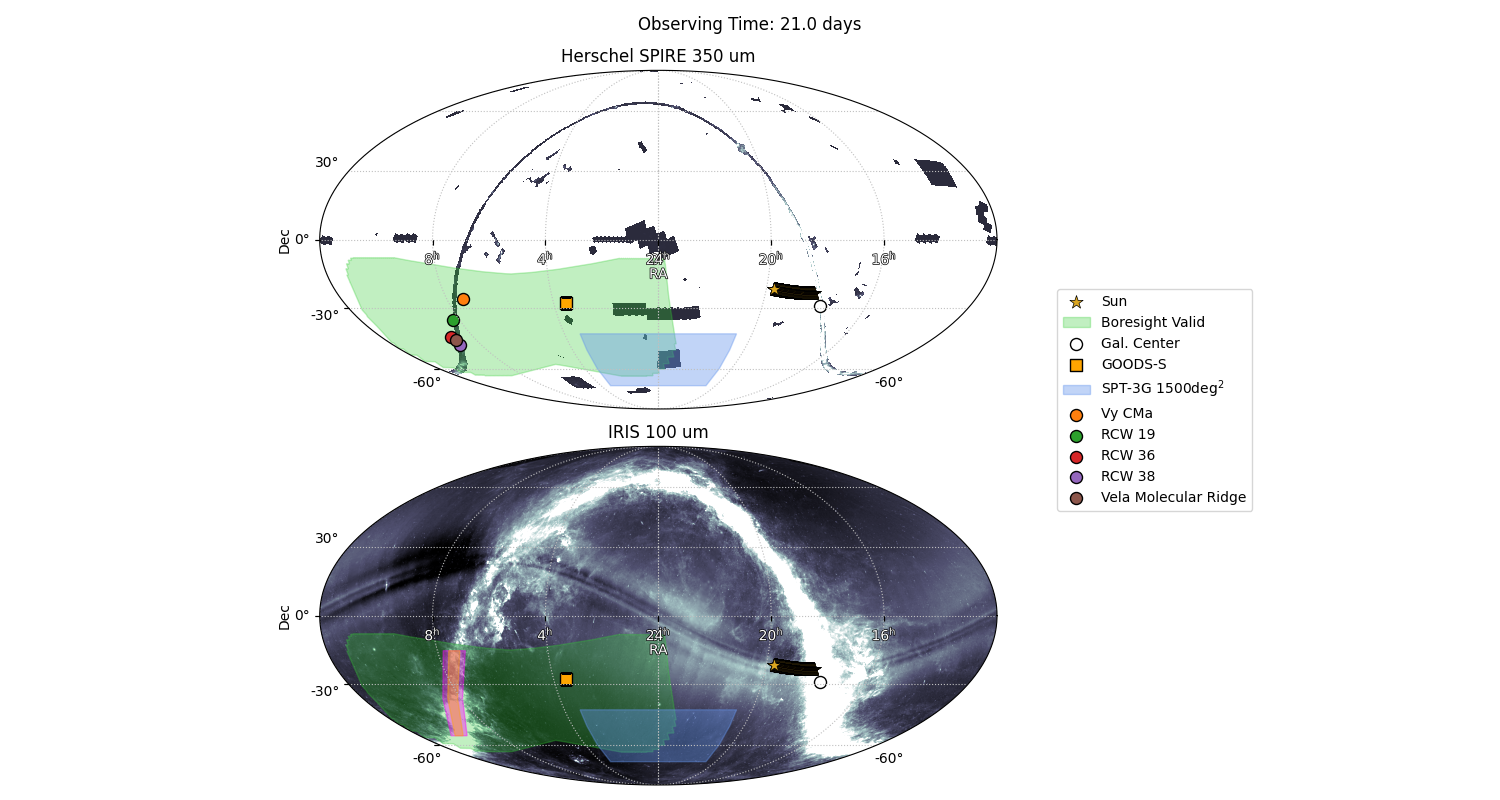

In [ ]:
fig, axs = plt.subplots(figsize=(15,8), nrows=2, subplot_kw=dict(projection=wcs, frame_class=EllipticalFrame), sharex=True, sharey=True)
ax0, ax1 = axs

for j, ax in enumerate(axs):
    d = ds[j]

    lon = ax.coords[0]
    lat = ax.coords[1]
    lat.set_axislabel_position("c")

    path_effects=[patheffects.withStroke(linewidth=1, foreground='black')]
    lon.set_ticklabel(color='white', path_effects=path_effects)
    ax.grid(linestyle=':', color='silver')

    ax.imshow(d, vmin=np.nanmin(d), vmax=np.nanmean(d) + 2 * np.nanstd(d), cmap='bone')

    p = ax.scatter(sun.ra, sun.dec, s=100, marker='*', facecolor='goldenrod', edgecolor='k', linewidth=.5, transform=ax.get_transform('icrs'), label='Sun')

    limleftup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limleftdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limleft(sun_altaz.az.deg) * u.deg)
    limrightup_radec = altaz_to_radec_helper(EL_MAX * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightmid_radec = altaz_to_radec_helper((EL_MAX + EL_MIN)/2 * u.deg, az_limright(sun_altaz.az.deg) * u.deg)
    limrightdown_radec = altaz_to_radec_helper(EL_MIN * u.deg, az_limright(sun_altaz.az.deg) * u.deg)

    # coordinates of corners on plot
    # p = ax.scatter(limleftup_radec.ra, limleftup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftmid_radec.ra, limleftmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limleftdown_radec.ra, limleftdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightup_radec.ra, limrightup_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightmid_radec.ra, limrightmid_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))
    # p = ax.scatter(limrightdown_radec.ra, limrightdown_radec.dec, marker='.', color='limegreen', alpha=0.4, transform=ax.get_transform('icrs'))

    rs = []
    for i in range(len(limleftup_radec)):
        verts = SkyCoord([
                limleftup_radec.ra[i],
                limleftmid_radec.ra[i],
                limleftdown_radec.ra[i],
                limrightdown_radec.ra[i],
                limrightmid_radec.ra[i],
                limrightup_radec.ra[i],
            ],
            [
                limleftup_radec.dec[i],
                limleftmid_radec.dec[i],
                limleftdown_radec.dec[i],
                limrightdown_radec.dec[i],
                limrightmid_radec.dec[i],
                limrightup_radec.dec[i],
            ],
            unit='deg',
            frame=ICRS
        )
        reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='limegreen', linewidth=2, facecolor=None))
        rs.append(reg)
    regions = Regions(rs)
    regions.write('myregions.reg', format='ds9', overwrite=True)

    px_regions = [r.to_pixel(wcs) for r in rs]
    """
    for i, p in enumerate(px_regions):
        if i == 0:
            p.plot(ax=ax, edgecolor='limegreen', facecolor='limegreen', alpha=max(1/len(times), 0.2), label='Boresight Valid')
        # p.plot(ax=ax, edgecolor='k', alpha=max(1/len(times), 0.01))
        p.plot(ax=ax, facecolor='none', edgecolor='limegreen', alpha=0.1)
    """
    from shapely.ops import unary_union
    from shapely.geometry import Polygon
    from regions import PolygonPixelRegion

    # Convert each sky region to pixel polygons
    px_regions = [r.to_pixel(wcs) for r in rs]

    # Extract vertices in pixel coordinates
    polygons = []
    for r in px_regions:
        x = r.vertices.x
        y = r.vertices.y
        polygons.append(Polygon(zip(x, y)))

    # Combine all footprints
    combined = unary_union(polygons)

    # Plot combined footprint
    if combined.geom_type == "Polygon":
        x, y = combined.exterior.xy
        ax.fill(x, y, facecolor="limegreen", edgecolor="limegreen",
                alpha=0.3, label="Boresight Valid")
        
    elif combined.geom_type == "MultiPolygon":
        for j, poly in enumerate(combined.geoms):
            x, y = poly.exterior.xy
            ax.fill(x, y, facecolor="limegreen", edgecolor="limegreen",
                    alpha=0.3, label="Boresight Valid" if j == 0 else None)

    # some additional points of interest
    ax.scatter(gal_center.ra, gal_center.dec, s=75, facecolor='w', edgecolor='k', transform=ax.get_transform('icrs'), label='Gal. Center')
    ax.scatter(goods_s.ra, goods_s.dec, s=75, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='GOODS-S', color='orange')
    #ax.scatter(edfs.ra, edfs.dec, s=75, marker='s', edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field South')
    # ax.scatter(edff.ra, edff.dec, marker='s', linewidth=0.5, edgecolor='k', transform=ax.get_transform('icrs'), label='Euclid Deep Field Fornax')

    verts = SkyCoord([
                '20h40m0s',
                '20h40m0s',
                '20h40m0s',
                '20h40m0s',
                '3h20m0s',
                '3h20m0s',
                '3h20m0s',
                '3h20m0s',
            ],
            [
                '-70d0m0s',
                '-60d0m0s',
                '-50d0m0s',
                '-42d0m0s',
                '-42d0m0s',
                '-50d0m0s',
                '-60d0m0s',
                '-70d0m0s',
            ],
            unit='deg',
            frame=ICRS
    )# https://www.researchgate.net/publication/348251485_Measurements_of_the_E-Mode_Polarization_and_Temperature-E-Mode_Correlation_of_the_CMB_from_SPT-3G_2018_Data/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6Il9kaXJlY3QiLCJwYWdlIjoiX2RpcmVjdCJ9fQ
    spt_reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='cornflowerblue', linewidth=1, facecolor=None))
    px_region = spt_reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='cornflowerblue', edgecolor='cornflowerblue', alpha=0.4, label='SPT-3G 1500deg$^2$')
    """

    verts = SkyCoord(
    ra=[
        "05h30m00s",
        "06h00m00s",
        "06h00m00s",
        "05h30m00s",
    ],
    dec=[
        "-30d00m00s",
        "-30d00m00s",
        "-45d00m00s",
        "-45d00m00s",
    ],
    frame="icrs",
    )

    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='orange', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='orange', edgecolor='orange', alpha=0.4, label='MBM53-55/HLCG-92-35 complex')
    """
    """
    verts = SkyCoord(
        ra=[
            "08h00m00s",
            "10h30m00s",
            "10h30m00s",
            "08h00m00s",
        ],
        dec=[
            "-38d00m00s",
            "-38d00m00s",
            "-57d00m00s",
            "-57d00m00s",
        ],
        frame="icrs",
    )


    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='magenta', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='magenta', edgecolor='magenta', alpha=0.4, label='Vela')
    """

    """
    verts = SkyCoord(
        ra=[
            "10h30m00s",
            "10h50m00s",
            "10h50m00s",
            "10h30m00s",
        ],
        dec=[
            "-58d00m00s",
            "-58d00m00s",
            "-60d00m00s",
            "-60d00m00s",
        ],
        frame="icrs",
    )


    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='red', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='red', edgecolor='red', alpha=0.4, label='Carina')


    verts = SkyCoord(
        ra=[
            "10h20m00s",
            "11h10m00s",
            "11h10m00s",
            "10h20m00s",
        ],
        dec=[
            "-57d00m00s",
            "-57d00m00s",
            "-61d00m00s",
            "-61d00m00s",
        ],
        frame="icrs",
    )

    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='red', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='red', edgecolor='red', alpha=0.4, )
    """

    '''
    verts = SkyCoord(
        ra=[
            "08h00m00s",
            "08h45m00s",
            "08h45m00s",
            "08h00m00s",
        ],
        dec=[
            "-29d00m00s",
            "-29d00m00s",
            "-53d00m00s",
            "-53d00m00s",
        ],
        frame="icrs",
    )

    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='purple', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='purple', edgecolor='purple', alpha=0.4,label='Cirus A' )
        
        
    verts = SkyCoord(
        ra=[
            "08h25m00s",
            "09h15m00s",
            "09h15m00s",
            "08h25m00s",
        ],
        dec=[
            "-27d00m00s",
            "-27d00m00s",
            "-55d00m00s",
            "-55d00m00s",
        ],
        frame="icrs",
    )
    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='indigo', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='indigo', edgecolor='indigo', alpha=0.4,label='Cirus B' )
    '''

    """
    verts = SkyCoord(
    ra=[
        "06h15m00s",
        "07h25m00s",
        "07h25m00s",
        "06h15m00s",
    ],
    dec=[
        "-10d00m00s",
        "-10d00m00s",
        "-40d00m00s",
        "-40d00m00s",
    ],
    frame="icrs",
    )
    
    reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='sienna', linewidth=1, facecolor=None))
    px_region = reg.to_pixel(wcs)
    px_region.plot(ax=ax, facecolor='sienna', edgecolor='sienna', alpha=0.4,label='outer‑Galaxy intermediate‑latitude' )
    """

    #for i in range(len(list_galactic_longitude_skycoord)): plot_from_catalog_helper(ax, list_galactic_longitude_skycoord[i], label=f'l={list_galactic_longitude[i]:.2f}deg',color=colors_longitues[i])
    
    #plot_from_catalog_helper(ax, "Cat's Paw Nebula")
    #plot_from_catalog_helper(ax, 'NGC 3576')
    #plot_from_catalog_helper(ax, 'Vela Molecular Ridge', color='orange')
    #plot_from_catalog_helper(ax, 'IRAS 08088-3554')
    #plot_from_catalog_helper(ax, 'CG 30')
    

    ax.set_xlabel('RA', color='w', path_effects=path_effects)
    ax.set_ylabel('Dec')

    if(j==0):
        plot_from_catalog_helper(ax, 'Vy CMa')
        rcw19 = plot_from_catalog_helper(ax, 'RCW 19')
        #rcw20 = plot_from_catalog_helper(ax, 'RCW 20')
        rcw36 = plot_from_catalog_helper(ax, 'RCW 36')
        rcw38 = plot_from_catalog_helper(ax, 'RCW 38')
        # plot_from_catalog_helper(ax, 'RCW 42')
        # plot_from_catalog_helper(ax, 'RCW 49')
        # carina = plot_from_catalog_helper(ax, 'Carina Nebula')
        #plot_from_catalog_helper(ax, 'NGC 253')
        # plot_from_catalog_helper(ax, 'HH 47')
        # plot_from_catalog_helper(ax, 'TW Hydrae')
        # plot_from_catalog_helper(ax, 'NGC 3576')
        # plot_from_catalog_helper(ax, 'NGC 3603')
        plot_from_catalog_helper(ax, 'Vela Molecular Ridge')
        
        # plot_from_catalog_helper(ax, 'Beta Gruis')
        # plot_from_catalog_helper(ax, '[MHL2007] G259.0453-01.5559 1') # Young Stellar Object Candidate
        # plot_from_catalog_helper(ax, 'NGC 2579')
        # plot_from_catalog_helper(ax, 'IRAS 08088-3554')
        # plot_from_catalog_helper(ax, 'CG 30')
        # plot_from_catalog_helper(ax, 'IRAS 08448-4343')
    else: 
        dra = 6.0  # degrees

        verts = SkyCoord(
            ra=[
                ra_extrems[0] - dra,
                ra_extrems[1] - dra,
                ra_extrems[2] - dra,
                ra_extrems[2] + dra,
                ra_extrems[1] + dra,
                ra_extrems[0] + dra,
            ] * u.deg,
            dec=[
                dec_extrems[0],
                dec_extrems[1],
                dec_extrems[2],
                dec_extrems[2],
                dec_extrems[1],
                dec_extrems[0],
            ] * u.deg,
            frame=ICRS(),
        )
        reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='magenta', linewidth=1, facecolor=None))
        px_region = reg.to_pixel(wcs)
        px_region.plot(ax=ax, facecolor='magenta', edgecolor='magenta', alpha=0.4, label='$\\pm$ 3deg from plane')
    

        dra = 3.0  # degrees

        verts = SkyCoord(
            ra=[
                ra_extrems[0] - dra,
                ra_extrems[1] - dra,
                ra_extrems[2] - dra,
                ra_extrems[2] + dra,
                ra_extrems[1] + dra,
                ra_extrems[0] + dra,
            ] * u.deg,
            dec=[
                dec_extrems[0],
                dec_extrems[1],
                dec_extrems[2],
                dec_extrems[2],
                dec_extrems[1],
                dec_extrems[0],
            ] * u.deg,
            frame=ICRS(),
        )
        reg = PolygonSkyRegion(vertices=verts, visual=dict(fill=True, edgecolor='orange', linewidth=1, facecolor=None))
        px_region = reg.to_pixel(wcs)
        px_region.plot(ax=ax, facecolor='orange', edgecolor='orange', alpha=0.4, label='$\\pm$ 6deg from plane')
    
        
        
    # fig.tight_layout()
#ax0.legend(loc='upper right', ncol=2, bbox_transform=fig.transFigure, bbox_to_anchor=(1., 0.8))
ax0.set_title('Herschel SPIRE 350 um')
ax1.set_title('IRIS 100 um')
fig.suptitle(f'Observing Time: {(t[-1] - t[0]).to(u.day).value:.1f} days')


handles, labels = ax0.get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(0.7, 0.5),
    frameon=True,
    ncol=1,
)
fig.tight_layout(rect=[0, 0, 0.85, 1])
